(100, 1)
(100, 1)


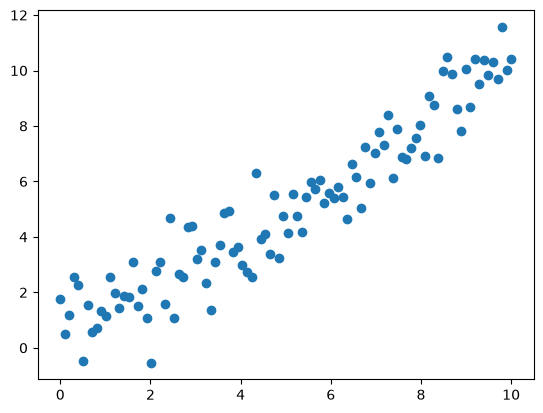

In [3]:
# présenter la structure de l'API scikit learn

# créer le dataset et le visualiser
import numpy as np 
import matplotlib.pyplot as plt 


# utiliser numpy pour créer le dataset
np.random.seed(0) # bloquer l'aléatoire

m = 100
# features ici 1 seule
X = np.linspace(0,10,m).reshape(m,1)
y = X + np.random.randn(m,1)

print(X.shape) # (100, 1)
print(y.shape) # (100, 1)
plt.scatter(X, y)

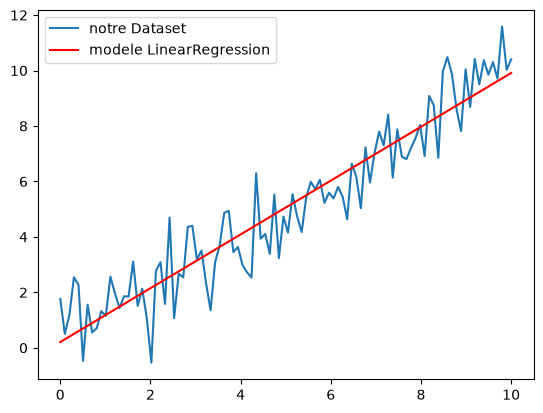

In [10]:
from sklearn.linear_model import LinearRegression

# créer le modèle
model = LinearRegression()

# entrainement
model.fit(X , y)

# évaluer la performance du notre modèle
model.score(X, y ) # 88,8% 

y_predict = model.predict( X )

plt.plot(X, y , label="notre Dataset")
plt.plot( X , y_predict , color="r" , label="modele LinearRegression")
plt.legend()


Utiliser scikit learn pour de la classification Utilisation du dataset du titanic

In [12]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
# dataset récupérer nos données

import seaborn as sns
import numpy as np

titanic = sns.load_dataset("titanic")

titanic.shape # numpy (891, 15)
titanic.head() # pandas

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic = titanic[["survived" , "pclass" , "sex" , "age" ]]

# transformer male en 0 et female en 1
# les modèles ne comprennent pas les textes
titanic["sex"] = titanic["sex"].map({ 'male' : 0 , 'female' : 1 })

titanic.dropna(axis=0, inplace=True)

titanic.describe()

y = titanic["survived"]
y = y.values.reshape(-1,1) # transformer les dimensions du vecteur
                           # (714,) => (714,1)
                           # Eviter les opérations de Broadcasting 

X = titanic.drop( ["survived"], axis=1 ) # (714, 3)

# verifier les dimensions  de X et y

# utilisation de scikit-learn
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

# apprendre
model.fit( X, y ) 

# les valeurs trouvées après l'apprentissage 
# meta paramètre du modèle KNeighborsClassifier
# n_neighbours = 5
# metric = minkowski

# évaluer performance du modèle
model.score( X,y ) # 0.8417366946778712 


# est ce que l'on aurait survecu au Titanic
# tester notre modèle
def survie(model , pclass=2 , sex=0 , age=40):
    moi = np.array([pclass , sex, age]).reshape(1,3)
    print(model.predict_proba(moi)) # [[0.8 0.2]]
    return model.predict( moi )


survie(model) # [0] non


[[0.8 0.2]]


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
# est ce que l'on aurait survecu au Titanic
# tester notre modèle
def survie(model , pclass=2 , sex=0 , age=40):
    moi = np.array([pclass , sex, age]).reshape(1,3)
    print(model.predict_proba(moi)) # [[0.8 0.2]]
    return model.predict( moi )

survie(model , pclass=3 , sex=1, age=20)

[[0.6 0.4]]


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

# rendre notre modèle plus performant et plus fiable 
# dataset en 2 parties 

- data_train 
- data_test
- data_validation

rdv dans 15 min => 10h45 bon café !!!!!!! @ toute suite


En Machine Learning il ne faut JAMAIS évaluer la performance de votre modèle sur les données d'entrainement

model = KNeighborsClassifier()

# apprendre
model.fit( X, y ) # données d'entrainement (passager tous)

# les valeurs trouvées après l'apprentissage 
# meta paramètre du modèle KNeighborsClassifier
# n_neighbours = 5
# metric = minkowski

# évaluer performance du modèle
model.score( X,y ) # 0.8417366946778712  (réutiliser les mêmes données)

ce qu'il est conseillé de faire => découper le dataset en 2 parties 

X , y

une partie pour l'entrainenemt => 80%

X_train , y_train => model.fit( X_train, y_train )

une deuxieme partie pour les tests de performance => 20%

X_test , y_test   => model.score( X_test, y_test )

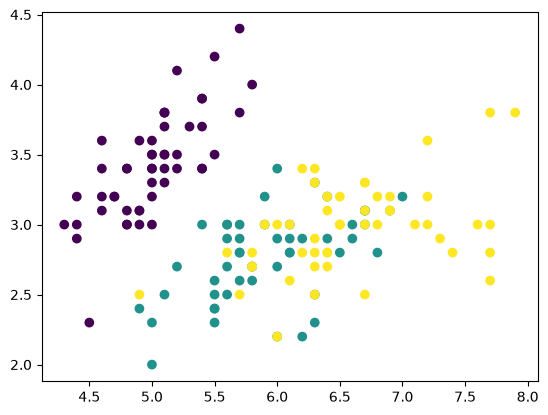

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris 

# Dataset complet

iris = load_iris()

X = iris.data
y = iris.target 

X.shape # (150, 4)
y = np.reshape(y,( y.shape[0] , 1)) # Broadcasting
y.shape  # (150,1)

plt.scatter(X[:,0],X[:,1], c=y )